# Preprocesamiento, Análisis Exploratorio y Entrenamiento de Modelos

### Estructura del notebook

| Sección | Contenido |
|---|---|
| 0–2 | Instalación, importaciones y parámetros globales |
| 3–6 | Carga, corrección de año, fusión LB × V-Dem, exclusiones |
| 7–8 | Recodificación del target y transformaciones de escala |
| **EDA Parte 1** | Exploración sobre datos transformados pre-split |
| 9–10 | Definición de features y construcción de splits temporales |
| **EDA Parte 2** | Validación post-transformación y selección empírica de features |
| 11–12 | Imputación diferenciada y función de evaluación |
| 13–17 | Cinco modelos con optimización Optuna |
| 18 | Ciclo principal de entrenamiento y guardado del pipeline completo |
| 19–21 | Función de predicción en producción, resultados y visualización |
| 22 | Registro de versiones |

> **Regla de oro anti-data leakage:** toda transformación aprendida (imputador, scaler)
> se ajusta **exclusivamente** sobre el conjunto de entrenamiento de cada split.

## 1. Importaciones

In [1]:
# =============================================================================
# Importaciones globales
# =============================================================================
import os, gc, json, joblib, warnings, logging
from pathlib import Path
from datetime import datetime
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import missingno as msno

from sklearn.experimental import enable_iterative_imputer   # noqa
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.linear_model import BayesianRidge, LogisticRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    balanced_accuracy_score, f1_score, cohen_kappa_score,
    roc_auc_score, mean_absolute_error,
)

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier, Pool
from pytorch_tabnet.tab_model import TabNetClassifier
import torch

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

from tqdm.notebook import tqdm

# Agregar raiz del proyecto al path (funciona en VS Code y Jupyter Lab)
import sys

_root = Path(".").resolve()
if not (_root / "utils").exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))


warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

print("✓ Importaciones completadas.")

✓ Importaciones completadas.


/home/mporras/DemocraticSatisfactionLatam/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Configuraciones personalizadas

In [2]:
from utils.config import (
    setup_plots, THEME, PALETTES, PARAMETERS, PATHS,
    SUBPERIODOS, SUBREGIONES, PAISES_EXCLUIR_TEST, AÑO_CORTE_VEN,
    MAPEO_NUMINVES, MAPEO_PAIS_ISO3,
    COL_TARGET, COL_AÑO, COL_PAIS, COL_ISO3, COL_PESO, NSNR,
    VARS_EXCLUIR_LB, VARS_EXCLUIR_VDEM,
    VARS_LIKERT4_INVERTIR, VARS_LIKERT4_INTERES, VARS_VDEM_INVERTIR,
    VARS_CATEGORICAS, N_CLASES, ETIQUETAS, BLOQUES, ETIQUETAS_FEATURES,
    bloque_de,
)
from utils.plots import save_figure, model_color
from utils.preprocessing import (
    limpiar_nsnr, construir_split, resumen_split, imputar, normalizar,
    aplicar_transformaciones_deterministas,
)
from utils.metrics import evaluar
from utils.models import (
    entrenar_olo, entrenar_xgboost, entrenar_catboost,
    entrenar_lightgbm, entrenar_tabnet, predecir,
)
setup_plots()
print("✓ Utils importados correctamente.")

✓ Utils importados correctamente.


## 2. Parámetros globales del pipeline

> Toda configuración ajustable se concentra aquí.
> Modificar este bloque sin tocar el resto del notebook.

In [3]:
# =============================================================================
# PARÁMETROS GLOBALES — solo configuración de ejecución y hardware
# =============================================================================

np.random.seed(PARAMETERS["SEED"])
torch.manual_seed(PARAMETERS["SEED"])

# ── Hardware ───────────────────────────────────────────────────────────────────
USAR_GPU       = True
DEVICE_CUDA    = "gpu"
DISPOSITIVO_TN = "cuda" if USAR_GPU and torch.cuda.is_available() else "cpu"
N_JOBS         = -1

# ── Directorios ───────────────────────────────────────────────────────────────
for d in [PATHS["FOLDER_PROCS"], PATHS["FOLDER_MODELS"], PATHS["FOLDER_RESULTS"],
          PATHS["FOLDER_RESULTS_FIGURES"], PATHS["FOLDER_RESULTS_METRICS"],
          PATHS["FOLDER_RESULTS_TABLES"]]:
    d.mkdir(parents=True, exist_ok=True)

# ── Flags de ejecución ────────────────────────────────────────────────────────
EJECUTAR_BUSQUEDA_HP = True   # False carga HPs ya guardados si existen
N_TRIALS_OPTUNA      = 50     # Reducir a 20 para pruebas rápidas

# ── Config de hardware para funciones de entrenamiento ────────────────────────
HW_CFG = {
    "usar_gpu"      : USAR_GPU,
    "device_cuda"   : DEVICE_CUDA,
    "dispositivo_tn": DISPOSITIVO_TN,
    "n_jobs"        : N_JOBS,
    "ejecutar_hp"   : EJECUTAR_BUSQUEDA_HP,
    "n_trials"      : N_TRIALS_OPTUNA,
}

print("✓ Parámetros globales cargados.")
print(f"  GPU disponible : {torch.cuda.is_available()}")
print(f"  Dispositivo    : {DISPOSITIVO_TN}")
print(f"  Semilla        : {PARAMETERS['SEED']}")
print(f"  Bloques temáticos definidos: {len(BLOQUES)}")
print(f"  Variables con etiqueta: {len(ETIQUETAS_FEATURES)}")

✓ Parámetros globales cargados.
  GPU disponible : True
  Dispositivo    : cuda
  Semilla        : 42
  Bloques temáticos definidos: 7
  Variables con etiqueta: 49


In [4]:
torch.cuda.is_available() 

True

## 3. Carga de datos consolidados

In [5]:
# =============================================================================
# Carga de Latinobarómetro y V-Dem
# =============================================================================
print("Cargando Latinobarómetro...")
df_lb_raw = pd.read_csv(PATHS["FILE_BASE_LB"], low_memory=False, encoding="utf-8-sig")
print(f"  {df_lb_raw.shape[0]:,} registros × {df_lb_raw.shape[1]} columnas")

print("Cargando V-Dem...")
df_vdem_raw = pd.read_csv(PATHS["FILE_BASE_VDEM"], low_memory=False, encoding="utf-8-sig")
print(f"  {df_vdem_raw.shape[0]:,} registros × {df_vdem_raw.shape[1]} columnas")

print()
print("Muestra LB (3 filas, primeras 8 columnas):")
print(df_lb_raw.iloc[:3, :8].to_string())
print()
print("Muestra V-Dem (3 filas):")
print(df_vdem_raw.head(3).to_string())

Cargando Latinobarómetro...


  489,771 registros × 43 columnas
Cargando V-Dem...
  540 registros × 28 columnas

Muestra LB (3 filas, primeras 8 columnas):
       ola  A_001_001  A_003_021  A_003_031  A_007_001  A_007_071  B_001_101  B_006_061
0  LAT2013        1.0        6.0        2.0        4.0        6.0        1.0        2.0
1  LAT2013        2.0        4.0        3.0        4.0        2.0        1.0        2.0
2  LAT2013        2.0        7.0        3.0        4.0        5.0        1.0        2.0

Muestra V-Dem (3 filas):
  country_name country_text_id  country_id  year  COWcode  v2x_polyarchy  v2x_libdem  v2x_partipdem  v2x_delibdem  v2x_egaldem  v2x_freexp_altinf  v2xcl_rol  v2x_jucon  v2xlg_legcon  v2x_cspart  v2x_egal  v2xeg_eqdr  v2x_accountability_osp  v2xnp_regcorr  v2x_neopat  v2xpe_exlsocgr  v2xpe_exlecon  v2x_corr  v2x_pubcorr  v2x_execorr  v2x_gender  v2x_rule  v2xcs_ccsi
0    Argentina             ARG          37  1995    160.0          0.833       0.641          0.575         0.773        0.657  

## 4. Corrección de la variable año y clave de fusión

`X_002` contiene el año calendario en la mayoría de olas, pero en cinco olas usa
el número de investigación: `16=2011`, `17=2013`, `18=2015`, `23=2023`, `24=2024`.
Esta corrección se aplica como primer paso antes de cualquier otra operación.

In [6]:
# =============================================================================
# Corrección de X_002 → año calendario
# =============================================================================
df_lb = df_lb_raw.copy()

if "ola" in df_lb.columns:
    df_lb[COL_AÑO] = df_lb["ola"].str.replace("LAT", "", regex=False).astype(int)
    print("✓ Año extraído desde columna 'ola'")
else:
    df_lb[COL_AÑO] = df_lb["X_002"].map(
        lambda x: MAPEO_NUMINVES.get(int(x), int(x))
    )
    print("✓ Año derivado de X_002 con corrección de numinves")

print()
print("Distribución de registros por año:")
for año, n in df_lb[COL_AÑO].value_counts().sort_index().items():
    print(f"  {int(año)}: {n:,}")

# Derivar ISO3
if COL_ISO3 not in df_lb.columns:
    print(f"\nDerivando ISO3 desde {COL_PAIS}...")
    df_lb[COL_ISO3] = df_lb[COL_PAIS].map(MAPEO_PAIS_ISO3)

n_sin = df_lb[COL_ISO3].isna().sum()
if n_sin > 0:
    print(f"\n⚠ Países sin ISO3: {df_lb[df_lb[COL_ISO3].isna()][COL_PAIS].unique()}")
else:
    print(f"\n✓ ISO3 derivado sin errores ({df_lb[COL_ISO3].nunique()} países)")

del df_lb_raw
gc.collect()

✓ Año extraído desde columna 'ola'

Distribución de registros por año:
  1995: 9,069
  1996: 21,200
  1997: 20,243
  1998: 20,331
  2000: 18,038
  2001: 20,631
  2002: 21,006
  2003: 21,133
  2004: 22,096
  2005: 20,222
  2006: 22,708
  2007: 22,694
  2008: 22,675
  2009: 22,690
  2010: 22,687
  2011: 20,204
  2013: 22,663
  2015: 20,250
  2016: 20,204
  2017: 20,200
  2018: 20,204
  2020: 20,204
  2023: 19,205
  2024: 19,214

⚠ Países sin ISO3: <ArrowStringArray>
[nan]
Length: 1, dtype: str


20

Eliminar registros sin país

In [7]:
# Eliminar todos los registros que no tengan nombre de país o año, ya que no se pueden usar para entrenamiento ni validación

df_lb = df_lb.dropna(subset=[COL_PAIS, COL_AÑO])


In [8]:
print(f"\nTamaño de la muestra final: {df_lb.shape[0]:,} registros × {df_lb.shape[1]} columnas")


Tamaño de la muestra final: 457,499 registros × 44 columnas


## 5. Fusión Latinobarómetro × V-Dem

In [9]:
# =============================================================================
# Merge LB × V-Dem por clave (pais_iso3, año)
# =============================================================================
df_vdem = df_vdem_raw.copy().rename(
    columns={"country_text_id": COL_ISO3, "year": COL_AÑO}
)
cols_drop = ["country_name", "country_id", "COWcode"] + VARS_EXCLUIR_VDEM
df_vdem   = df_vdem[[c for c in df_vdem.columns if c not in cols_drop]]

n_vdem_feat = len([c for c in df_vdem.columns if c not in [COL_ISO3, COL_AÑO]])
print(f"Variables V-Dem a fusionar: {n_vdem_feat}")

df = df_lb.merge(df_vdem, on=[COL_ISO3, COL_AÑO], how="left", validate="m:1")

n_sin_vdem = df["v2x_polyarchy"].isna().sum()
pct_ok     = (1 - n_sin_vdem / len(df)) * 100
print(f"\nResultado del merge:")
print(f"  Registros totales  : {len(df):,}")
print(f"  Con V-Dem completo : {len(df) - n_sin_vdem:,} ({pct_ok:.1f}%)")
print(f"  Sin V-Dem          : {n_sin_vdem:,}")
print(f"  Columnas totales   : {df.shape[1]}")

# ── Auditoría de cobertura V-Dem ──────────────────────────────────────────────
# Los NaN en índices V-Dem post-merge son Missing Not At Random (MNAR):
# su ausencia refleja que el país no tenía datos institucionales para ese año,
# lo que es en sí mismo información relevante para el análisis.
# Se documentan aquí para justificar el supuesto de imputabilidad.
vdem_cols_check = ["v2x_polyarchy", "v2x_libdem", "v2x_corr"]
vdem_check = [c for c in vdem_cols_check if c in df.columns]
if vdem_check:
    print()
    print("Auditoría de cobertura V-Dem post-merge:")
    sin_vdem = df[df[vdem_check[0]].isna()]
    if len(sin_vdem) > 0:
        print(f"  Registros sin datos V-Dem: {len(sin_vdem):,} ({len(sin_vdem)/len(df)*100:.1f}%)")
        print("  Distribución por país:")
        for pais, n in sin_vdem[COL_PAIS].value_counts().head(10).items():
            print(f"    {pais:<25}: {n:,} registros")
        años_sin = sorted(sin_vdem[COL_AÑO].unique())
        print(f"  Años afectados: {años_sin}")
        print("  Nota: estos NaN se imputarán con MICE para OLO y TabNet.")
        print("        Los modelos de árboles los manejan nativamente.")
    else:
        print("  ✓ Cobertura V-Dem completa para todos los registros.")

del df_lb, df_vdem, df_vdem_raw
gc.collect()

Variables V-Dem a fusionar: 19

Resultado del merge:
  Registros totales  : 457,499
  Con V-Dem completo : 457,499 (100.0%)
  Sin V-Dem          : 0
  Columnas totales   : 63

Auditoría de cobertura V-Dem post-merge:
  ✓ Cobertura V-Dem completa para todos los registros.


0

## 6. Exclusiones iniciales

In [10]:
# =============================================================================
# Exclusiones de variables y registros
# =============================================================================

# Paso 1: variables LB descartadas
excl = [c for c in VARS_EXCLUIR_LB if c in df.columns]
df   = df.drop(columns=excl)
print(f"Variables LB excluidas: {excl}")

# Paso 2: registros sin target válido
mask_inv = df["A_003_031"].isna() | df["A_003_031"].isin(NSNR)
n_inv    = mask_inv.sum()
df       = df[~mask_inv].copy()
print(f"Registros excluidos por target NS/NR: {n_inv:,}")

# Paso 3: Venezuela post-2017
mask_ven = (df[COL_PAIS] == "Venezuela") & (df[COL_AÑO] > AÑO_CORTE_VEN)
n_ven    = mask_ven.sum()
df       = df[~mask_ven].copy()
print(f"Registros Venezuela post-{AÑO_CORTE_VEN} excluidos: {n_ven:,}")

# Paso 4: años fuera del rango del estudio
# IMPORTANTE: incluir también validate_ola para que construir_split()
# encuentre registros en el conjunto de validación de cada subperiodo.
# (SP3 usa 2023 como validación; sin esta línea esos registros se eliminan.)
años_validos = set()
for cfg in SUBPERIODOS.values():
    años_validos.update(cfg["train_olas"])
    años_validos.update(cfg["validate_ola"])
    años_validos.update(cfg["test_ola"])
n_antes = len(df)
df      = df[df[COL_AÑO].isin(años_validos)].copy()
print(f"Registros con año fuera del rango: {n_antes - len(df):,}")

print(f"\nDataset tras exclusiones: {df.shape[0]:,} × {df.shape[1]}")
print(f"Países : {df[COL_PAIS].nunique()}")
print(f"Años   : {sorted(df[COL_AÑO].unique())}")
gc.collect()

Variables LB excluidas: ['C_001_031', 'A_003_021', 'D_001_061', 'D_001_131', 'X_004', 'S_700']


Registros excluidos por target NS/NR: 21,036
Registros Venezuela post-2017 excluidos: 4,707
Registros con año fuera del rango: 0

Dataset tras exclusiones: 431,756 × 57
Países : 18
Años   : [np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2013), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2020), np.int64(2023), np.int64(2024)]


0

## 7. Recodificación de la variable dependiente

In [11]:
# =============================================================================
# Recodificación A_003_031 → target base 0: {0, 1, 2, 3}
# =============================================================================
vals = sorted(df["A_003_031"].dropna().unique())
assert set(int(v) for v in vals) == {1, 2, 3, 4}, f"Escala inesperada: {vals}"

df[COL_TARGET] = df["A_003_031"].map({1.0:0, 2.0:1, 3.0:2, 4.0:3})
assert df[COL_TARGET].isna().sum() == 0, "NaN inesperados en target"

print("Distribución del target recodificado:")
dist = df[COL_TARGET].value_counts().sort_index()
for cls, n in dist.items():
    print(f"  Clase {int(cls)}: {n:>8,} ({n/len(df)*100:.1f}%) — {ETIQUETAS[cls]}")

# Pesos inversos de clase para manejo del desbalance sin SMOTE
PESOS_CLASE = {
    cls: len(df) / (N_CLASES * (df[COL_TARGET] == cls).sum())
    for cls in range(N_CLASES)
}
print("\nPesos inversos de clase:")
for cls, w in PESOS_CLASE.items():
    print(f"  Clase {cls} ({ETIQUETAS[cls]:<25}): {w:.4f}")

Distribución del target recodificado:
  Clase 0:   41,437 (9.6%) — Para nada satisfecho
  Clase 1:  112,974 (26.2%) — No muy satisfecho
  Clase 2:  187,030 (43.3%) — Más bien satisfecho
  Clase 3:   90,315 (20.9%) — Muy satisfecho

Pesos inversos de clase:
  Clase 0 (Para nada satisfecho     ): 2.6049
  Clase 1 (No muy satisfecho        ): 0.9554
  Clase 2 (Más bien satisfecho      ): 0.5771
  Clase 3 (Muy satisfecho           ): 1.1951


## 8. Transformaciones de escala

Se aplica la convención de **mayor valor = más favorable** de forma consistente.
El orden es crítico: NS/NR → NaN primero, luego inversiones, para evitar que
valores especiales generen datos ficticios.

In [12]:
# =============================================================================
# Transformaciones de escala — orden obligatorio
# (limpiar_nsnr importada desde utils.preprocessing)
# =============================================================================

# ── Paso 1: NS/NR → NaN en todas las columnas relevantes ─────────────────────
cols_limpiar = [c for c in df.columns
                if c not in [COL_TARGET, COL_AÑO, COL_PESO,
                              "A_003_031", COL_ISO3, COL_PAIS, "ola"]]
df = limpiar_nsnr(df, cols_limpiar, NSNR)
print("✓ NS/NR → NaN")

# ── Paso 2: Valores especiales adicionales ────────────────────────────────────
if "A_007_071" in df.columns:
    df.loc[df["A_007_071"] == 97, "A_007_071"] = np.nan
if "C_003_003_011" in df.columns:
    df.loc[df["C_003_003_011"] == 5, "C_003_003_011"] = np.nan
print("✓ Valores especiales adicionales")

# ── Paso 3: Inversión Likert 4 pts — confianza institucional (5 - x) ─────────
for col in VARS_LIKERT4_INVERTIR:
    if col not in df.columns:
        continue
    mask = df[col].notna() & df[col].between(1, 4)
    df.loc[mask, col] = 5 - df.loc[mask, col]
    n_fuera = (df[col].notna() & ~df[col].between(1, 4)).sum()
    if n_fuera > 0:
        df.loc[df[col].notna() & ~df[col].between(1, 4), col] = np.nan
print(f"✓ Confianza institucional invertida ({len(VARS_LIKERT4_INVERTIR)} variables)")

# ── Paso 4: Inversión interés en política (5 - x) ────────────────────────────
for col in VARS_LIKERT4_INTERES:
    if col not in df.columns:
        continue
    mask = df[col].notna() & df[col].between(1, 4)
    df.loc[mask, col] = 5 - df.loc[mask, col]
print(f"✓ Interés en política invertido: {VARS_LIKERT4_INTERES}")

# ── Paso 5: Evaluaciones económicas comparativas ──────────────────────────────
for col in ["D_001_021", "D_001_041", "D_001_091"]:
    if col not in df.columns:
        continue
    mask3 = (df[COL_AÑO] <= 2000) & df[col].between(1, 3)
    mask5 = (df[COL_AÑO] >= 2001) & df[col].between(1, 5)
    df.loc[mask3, col] = 4 - df.loc[mask3, col]
    df.loc[mask5, col] = 6 - df.loc[mask5, col]
print("✓ Evaluaciones económicas comparativas armonizadas")

# ── Paso 6: Recodificaciones binarias ─────────────────────────────────────────
# Se usa np.select en lugar de .map() para evitar que valores no contemplados
# se conviertan silenciosamente a NaN. Los valores fuera de {1.0, 2.0} se
# marcan explícitamente como NaN con condición residual documentada.
recodif = {
    "B_006_061": {1.0: 1, 2.0: 0},   # Aprueba=1, Desaprueba=0
    "B_001_101": {1.0: 1, 2.0: 0},   # País para todos=1, para poderosos=0
    "H_001_011": {1.0: 1, 2.0: 0},   # Confianza: Sí=1, No=0
    "S_001"    : {1.0: 0, 2.0: 1},   # Sexo: Hombre=0, Mujer=1
}
for col, mapeo in recodif.items():
    if col not in df.columns:
        continue
    nan_antes = int(df[col].isna().sum())
    condiciones  = [df[col] == k for k in mapeo]
    valores      = list(mapeo.values())
    df[col] = np.select(condiciones, valores, default=np.nan)
    nan_despues = int(df[col].isna().sum())
    delta = nan_despues - nan_antes
    if delta > 0:
        print(f"  ⚠ {col}: {delta} valores no contemplados → NaN (antes: {nan_antes}, después: {nan_despues})")
print(f"✓ Recodificaciones binarias: {list(recodif.keys())}")

# ── Paso 7: Victimización I_001_001 — 3 períodos de codificación ──────────────
if "I_001_001" in df.columns:
    col   = "I_001_001"
    nueva = np.full(len(df), np.nan)
    m_bin  = (df[COL_AÑO] <= 2008).values
    nueva[m_bin & (df[col].values == 1)] = 1
    nueva[m_bin & (df[col].values == 2)] = 0
    m_09   = (df[COL_AÑO] == 2009).values
    nueva[m_09 & np.isin(df[col].values, [1, 2])] = 1
    nueva[m_09 & (df[col].values == 3)]            = 0
    m_post = (df[COL_AÑO] >= 2010).values
    nueva[m_post & np.isin(df[col].values, [1, 2, 3])] = 1
    nueva[m_post & (df[col].values == 4)]               = 0
    df[col] = nueva
print("✓ Victimización recodificada (3 períodos → binaria)")

# ── Paso 8: G_002_011 — corrupción experiencial (LAT2013 con escala anómala) ──
# Olas estándar: 1=Sí conoce, 2=No conoce → recodificar a 1/0.
# LAT2013: escala {1,2,3,4,5} → 1=Sí, >1=No.
# Cualquier valor no contemplado → NaN explícito (evita valores inválidos).
if "G_002_011" in df.columns:
    col = "G_002_011"
    nueva = np.full(len(df), np.nan)
    # Olas estándar (≠ 2013)
    m_std = (df[COL_AÑO] != 2013).values
    nueva[m_std & (df[col].values == 1)] = 1
    nueva[m_std & (df[col].values == 2)] = 0
    # LAT2013
    m_13  = (df[COL_AÑO] == 2013).values
    nueva[m_13 & (df[col].values == 1)] = 1
    nueva[m_13 & (df[col].values >  1) & df[col].notna().values] = 0
    # Conteo de valores residuales que quedan como NaN
    n_residual = int(df[col].notna().sum()) - int(np.sum(nueva == 1) + np.sum(nueva == 0))
    if n_residual > 0:
        print(f"  ⚠ G_002_011: {n_residual} valores residuales → NaN")
    df[col] = nueva
print("✓ Corrupción experiencial recodificada")

# ── Paso 9: V-Dem — índices de corrupción (1 - x) ────────────────────────────
for col in VARS_VDEM_INVERTIR:
    if col in df.columns:
        df[col] = 1.0 - df[col]
print(f"✓ Índices V-Dem invertidos: {VARS_VDEM_INVERTIR}")
print("  Semántica post-inversión: mayor valor = menor corrupción")

# ── Auditoría de NaN post-transformación ─────────────────────────────────────
# Verificar que no se introdujeron NaN inesperados durante las transformaciones.
# Las variables con NaN esperados son aquellas ausentes en ciertas olas.
print()
print("=" * 55)
print(f"  Dataset final: {df.shape[0]:,} × {df.shape[1]}")
print(f"  Missingness global: {df.isnull().mean().mean()*100:.1f}%")
print()
print("  Variables con >30% de NaN (requieren imputación significativa):")
nan_pct = df.isnull().mean().sort_values(ascending=False)
vars_alta_nan = nan_pct[nan_pct > 0.30]
cols_meta = {COL_AÑO, COL_PAIS, COL_ISO3, COL_PESO, "A_003_031", "ola", COL_TARGET}
vars_alta_nan = vars_alta_nan[~vars_alta_nan.index.isin(cols_meta)]
if vars_alta_nan.empty:
    print("    Ninguna variable supera el 30% de NaN.")
else:
    for col, pct in vars_alta_nan.items():
        print(f"    {col:<25}: {pct*100:.1f}%")

✓ NS/NR → NaN
✓ Valores especiales adicionales
✓ Confianza institucional invertida (9 variables)
✓ Interés en política invertido: ['A_007_001']
✓ Evaluaciones económicas comparativas armonizadas
  ⚠ B_001_101: 67 valores no contemplados → NaN (antes: 141783, después: 141850)
✓ Recodificaciones binarias: ['B_006_061', 'B_001_101', 'H_001_011', 'S_001']
✓ Victimización recodificada (3 períodos → binaria)
✓ Corrupción experiencial recodificada
✓ Índices V-Dem invertidos: ['v2x_corr', 'v2x_execorr', 'v2x_pubcorr']
  Semántica post-inversión: mayor valor = menor corrupción

  Dataset final: 431,756 × 58
  Missingness global: 7.9%

  Variables con >30% de NaN (requieren imputación significativa):
    G_005_001                : 40.8%
    C_006_003_011            : 38.1%
    A_007_001                : 35.9%
    C_003_003_011            : 34.3%
    B_001_101                : 32.9%
    G_002_011                : 32.8%


## EDA — Parte 1: Exploración del dataset integrado

Análisis sobre el dataset completo post-transformación y pre-split.
Objetivo: comprender la distribución del target, el patrón de missingness
y las características globales antes de particionar en subperiodos.

  ✓ Figura guardada: eda1_target_subperiodos.png.png


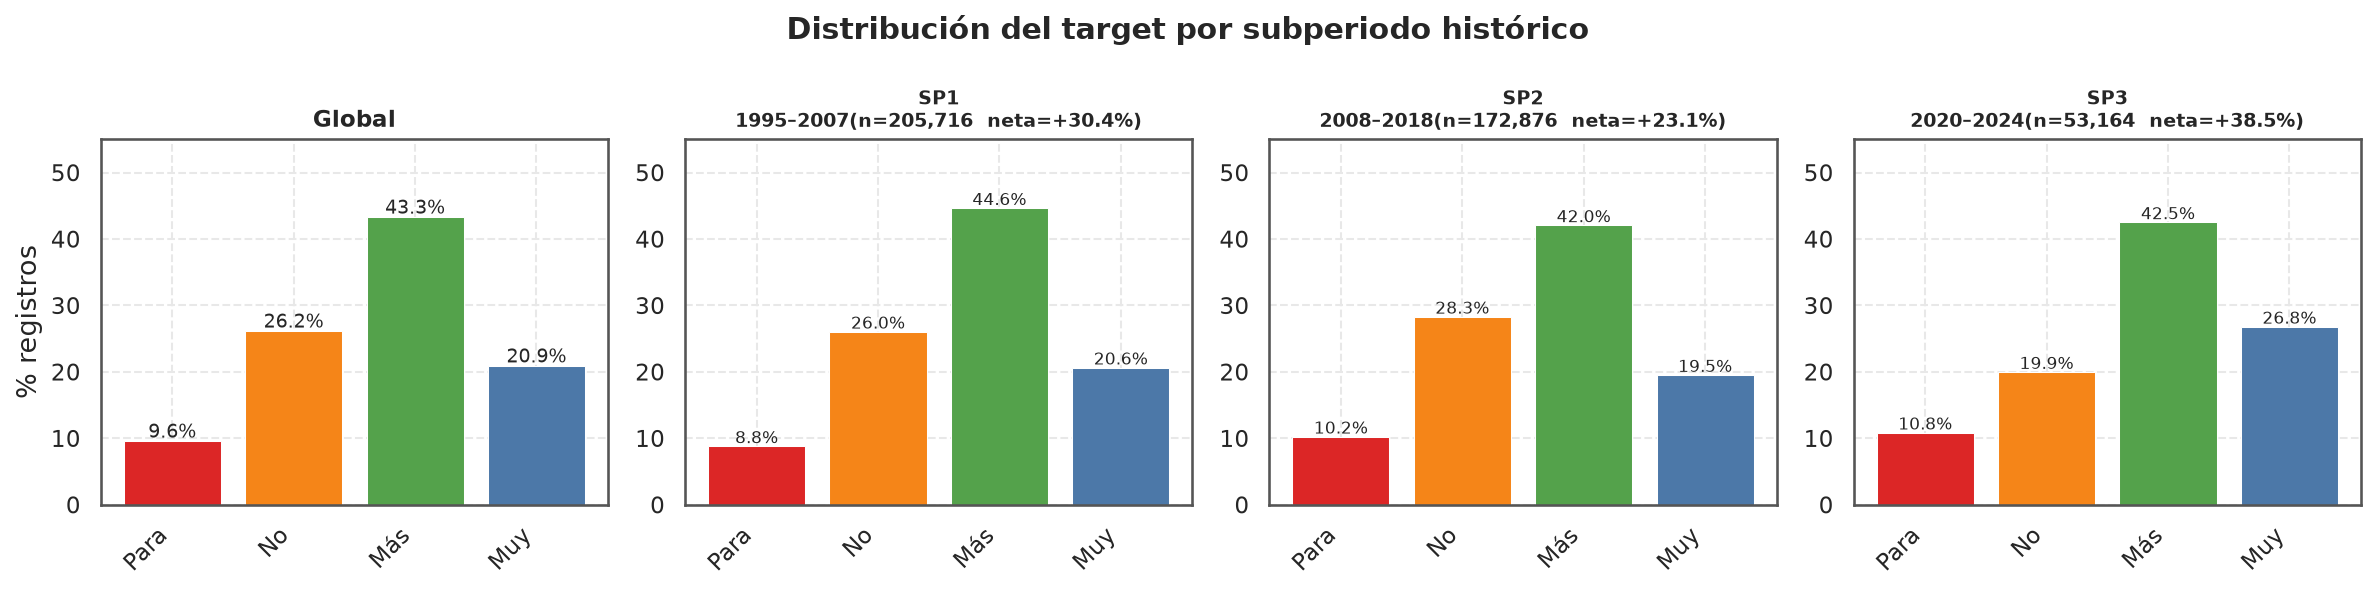

✓ Figura guardada: eda1_target_subperiodos.png


In [13]:
# =============================================================================
# EDA 1.1 — Distribución del target por subperiodo histórico
# =============================================================================
SP_HIST = {
    "SP1\n1995–2007": [1995,1996,1997,1998,2000,2001,2002,2003,2004,2005,2006,2007],
    "SP2\n2008–2018": [2008,2009,2010,2011,2013,2015,2016,2017,2018],
    "SP3\n2020–2024": [2020,2023,2024],
}
colores_cls = [THEME["target"][i] for i in range(4)]

fig, axes = plt.subplots(1, len(SP_HIST) + 1, figsize=(16, 4))

# Panel global
ax = axes[0]
vals_g = df[COL_TARGET].value_counts(normalize=True).sort_index() * 100
etiq_cortas = [v.split()[0] for v in ETIQUETAS.values()]
ax.bar(etiq_cortas, vals_g.values, color=colores_cls, edgecolor="white", linewidth=0.5)
ax.set_title("Global", fontweight="bold", fontsize=11)
ax.set_ylabel("% registros")
ax.set_ylim(0, 55)
for i, v in enumerate(vals_g.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9)

# Paneles por subperiodo
for ax, (sp_label, años) in zip(axes[1:], SP_HIST.items()):
    sub  = df[df[COL_AÑO].isin(años)]
    vals = sub[COL_TARGET].value_counts(normalize=True).sort_index() * 100
    neta = (vals.get(2, 0) + vals.get(3, 0)) - (vals.get(0, 0) + vals.get(1, 0))
    bars = [vals.get(i, 0) for i in range(4)]
    ax.bar(etiq_cortas, bars, color=colores_cls, edgecolor="white", linewidth=0.5)
    ax.set_title(f"{sp_label}(n={len(sub):,}  neta={neta:+.1f}%)",
                 fontsize=9, fontweight="bold")
    ax.set_ylim(0, 55)
    for i, v in enumerate(bars):
        ax.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=8)

fig.suptitle("Distribución del target por subperiodo histórico", fontweight="bold")
for ax in axes:
    ax.tick_params(axis="x", labelrotation=45)
    plt.setp(ax.get_xticklabels(), ha="right")
save_figure("eda1_target_subperiodos.png")
plt.show()
print("✓ Figura guardada: eda1_target_subperiodos.png")

  ✓ Figura guardada: eda1_missingness_heatmap.png.png


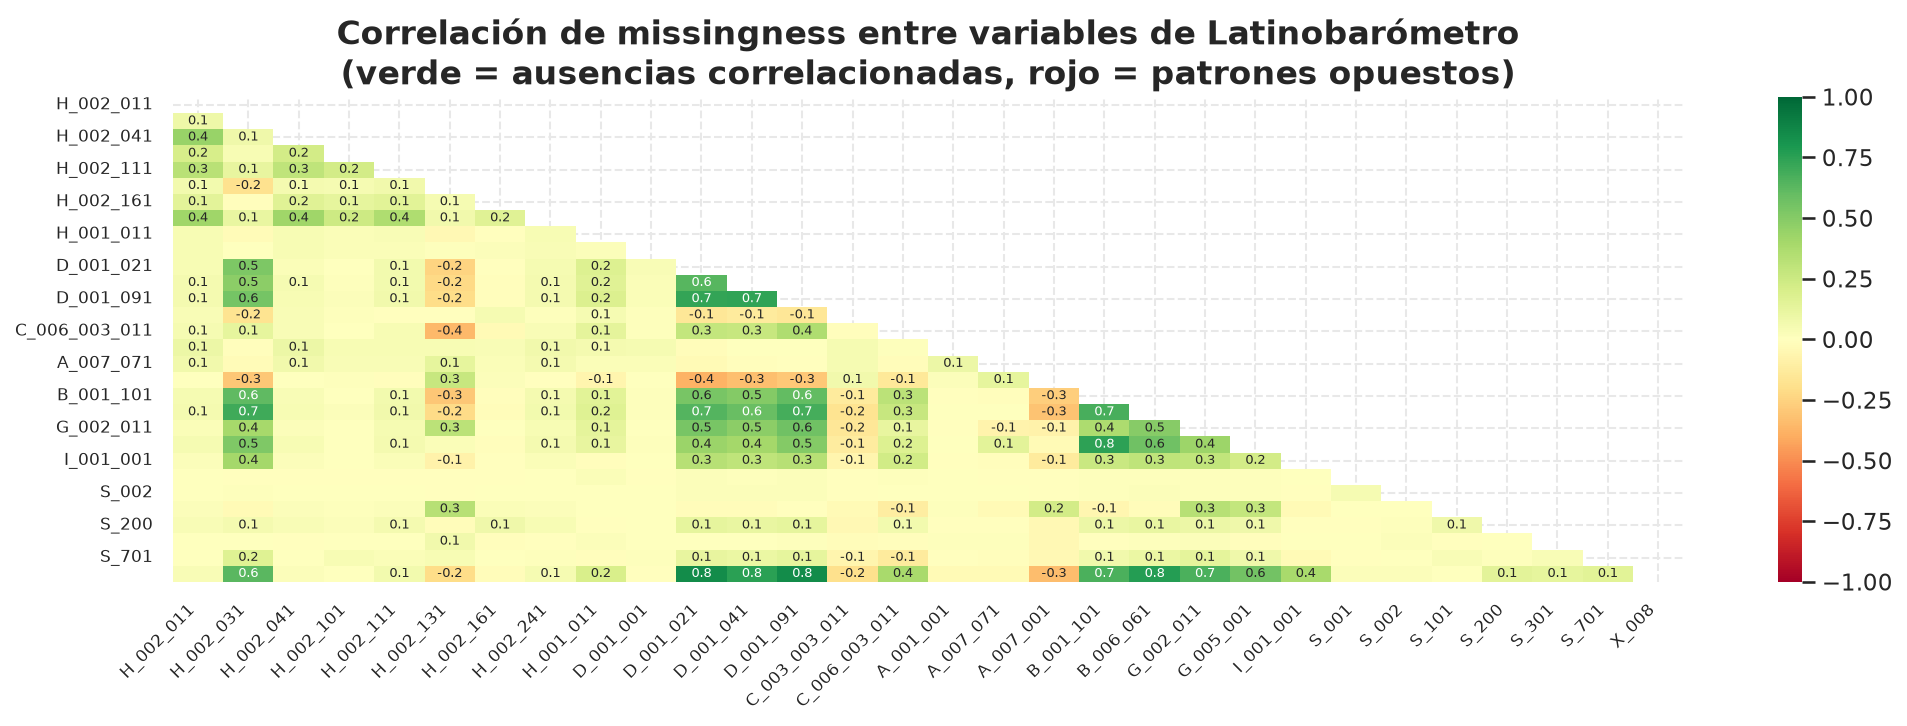

Cobertura por variable (% de valores válidos):
  Variable                  Etiqueta                         Bloque                         Cobertura
  ───────────────────────────────────────────────────────────────────────────────────────────────
  H_002_011                 Confianza Congreso               Confianza institucional         96.8%
  H_002_031                 Confianza Gobierno               Confianza institucional         83.1%
  H_002_041                 Confianza Poder Judicial         Confianza institucional         97.3%
  H_002_101                 Confianza Iglesia Católica       Confianza institucional         98.6%
  H_002_111                 Confianza Policía                Confianza institucional         98.7%
  H_002_131                 Confianza Televisión             Confianza institucional         77.2%
  H_002_161                 Confianza FF.AA.                 Confianza institucional         89.4%
  H_002_241                 Confianza Partidos Políticos    

In [14]:
# =============================================================================
# EDA 1.2 — Heatmap de missingness y tabla de cobertura por variable
# =============================================================================
# Solo las features del modelo (sin columnas de metadata)
FEATURES_EDA = []
for bloque, variables in BLOQUES.items():
    if "V-Dem" not in bloque:   # LB features
        FEATURES_EDA.extend([v for v in variables if v in df.columns])
FEATURES_EDA = list(dict.fromkeys(FEATURES_EDA))  # sin duplicados

fig, ax = plt.subplots(figsize=(14, 5))
msno.heatmap(df[FEATURES_EDA], ax=ax, fontsize=8, cmap="RdYlGn",
             labels=[ETIQUETAS_FEATURES.get(c, c) for c in FEATURES_EDA])
ax.set_title("Correlación de missingness entre variables de Latinobarómetro\n"
             "(verde = ausencias correlacionadas, rojo = patrones opuestos)",
             fontweight="bold")
save_figure("eda1_missingness_heatmap.png")
plt.show()

# Tabla de cobertura
print("Cobertura por variable (% de valores válidos):")
print(f"  {'Variable':<25} {'Etiqueta':<32} {'Bloque':<30} {'Cobertura'}")
print("  " + "─" * 95)
for col in FEATURES_EDA:
    cob = (1 - df[col].isnull().mean()) * 100
    et  = ETIQUETAS_FEATURES.get(col, col)
    bl  = bloque_de(col)
    print(f"  {col:<25} {et:<32} {bl:<30} {cob:>5.1f}%")

  ✓ Figura guardada: eda1_missingness_por_split.png.png


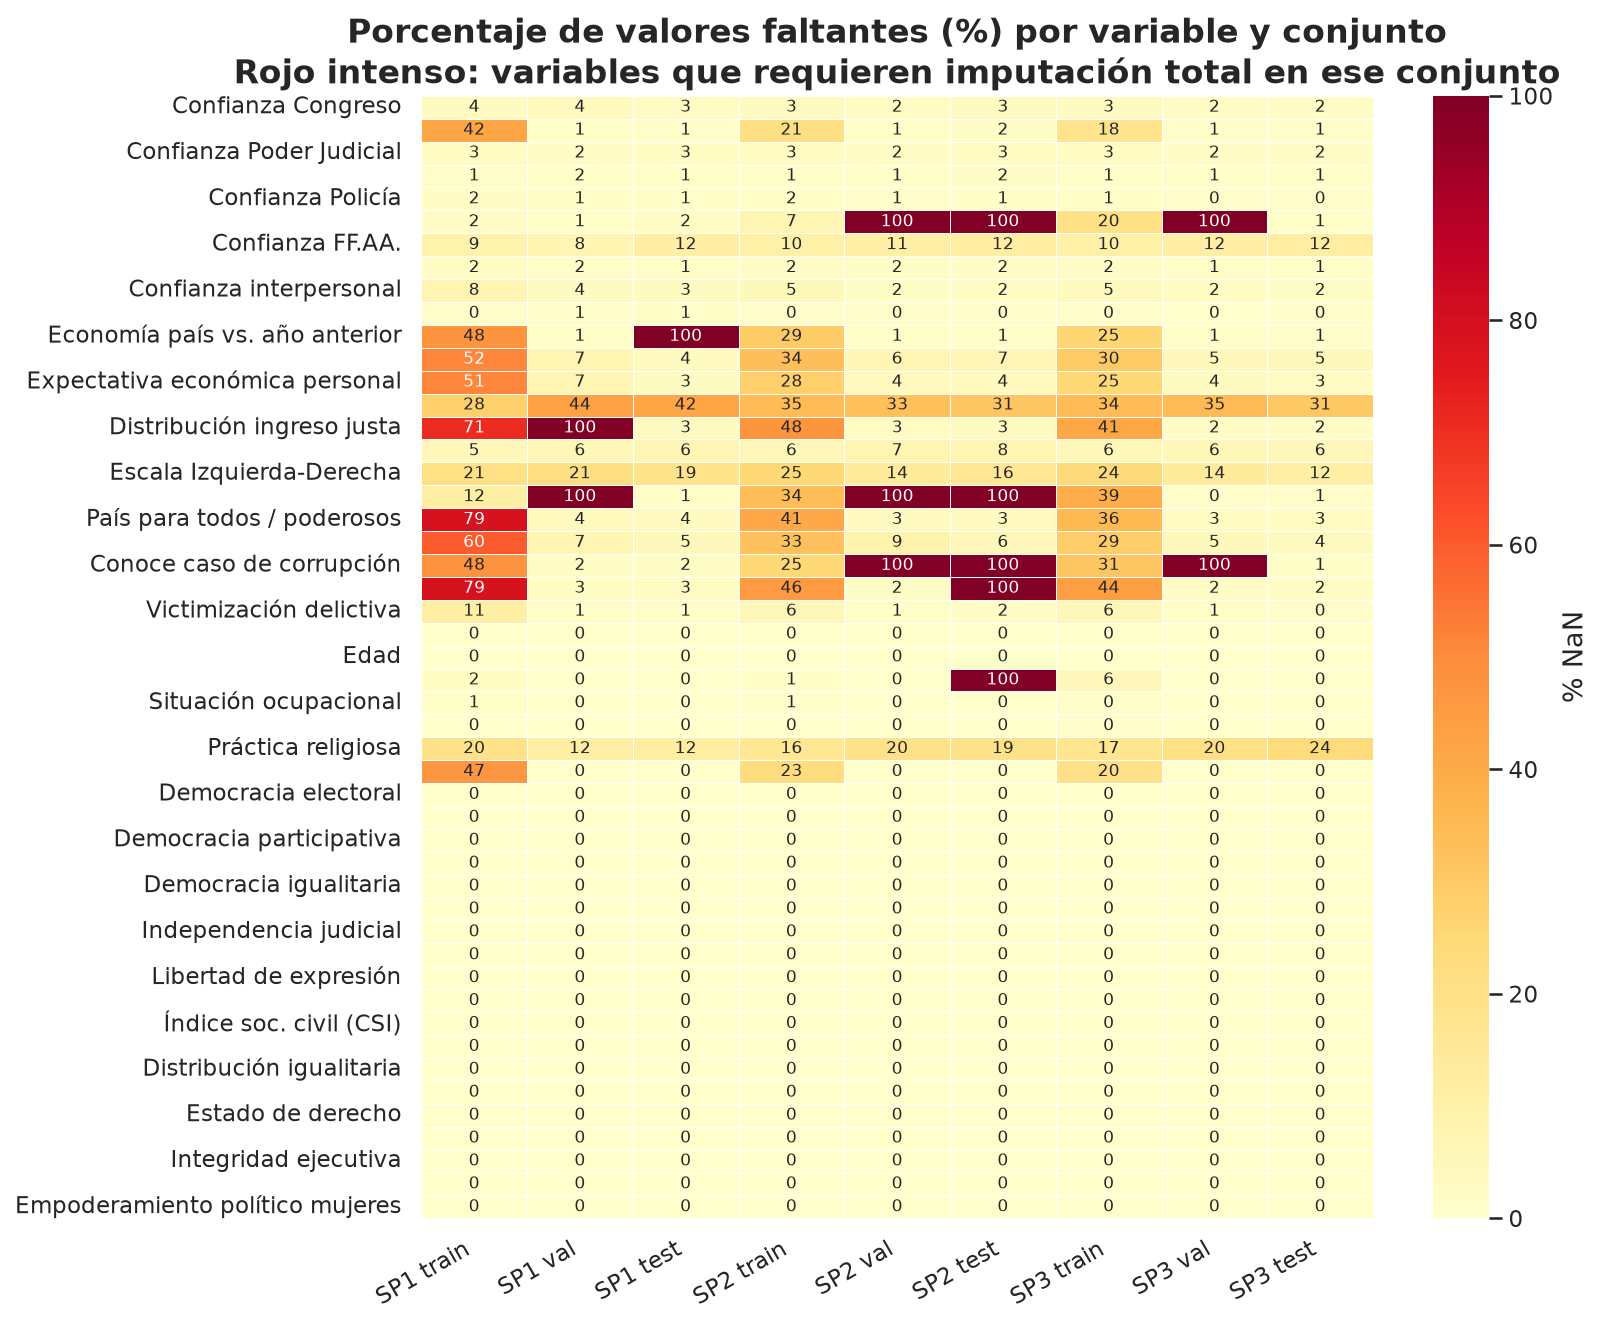

Variables con 100% de faltantes en algún conjunto de prueba:
  H_002_131 (Confianza Televisión): 100% NaN en ['SP2 val', 'SP2 test', 'SP3 val']
  D_001_021 (Economía país vs. año anterior): 100% NaN en ['SP1 test']
  C_006_003_011 (Distribución ingreso justa): 100% NaN en ['SP1 val']
  A_007_001 (Interés en política): 100% NaN en ['SP1 val', 'SP2 val', 'SP2 test']
  G_002_011 (Conoce caso de corrupción): 100% NaN en ['SP2 val', 'SP2 test', 'SP3 val']
  G_005_001 (Progreso contra corrupción): 100% NaN en ['SP2 test']
  S_101 (Nivel educativo): 100% NaN en ['SP2 test']
  (Estas variables se imputan completamente con la media/moda del train)


In [15]:
# =============================================================================
# EDA 1.3 — Missingness por variable y por split (train/test de cada SP)
# =============================================================================
SP_SPLITS = {
    "SP1 train": [1995,1996,1997,1998,2000,2001,2002,2003,2004,2005],
    "SP1 val"  : [2006],
    "SP1 test" : [2007],
    "SP2 train": [1995,1996,1997,1998,2000,2001,2002,2003,2004,2005,2006,
                  2007,2008,2009,2010,2011,2013,2015,2016],
    "SP2 val"  : [2017],
    "SP2 test" : [2018],
    "SP3 train": [1995,1996,1997,1998,2000,2001,2002,2003,2004,2005,2006,
                  2007,2008,2009,2010,2011,2013,2015,2016,2017,2018,2020],
    "SP3 val"  : [2023],
    "SP3 test" : [2024],
}

miss_sp = {}
for sp_name, años in SP_SPLITS.items():
    sub = df[df[COL_AÑO].isin(años)][FEATURES_EDA]
    miss_sp[sp_name] = (sub.isnull().mean() * 100).round(1)

df_miss_sp = pd.DataFrame(miss_sp)
# Etiquetas cortas para el eje Y
df_miss_sp.index = [ETIQUETAS_FEATURES.get(c, c) for c in FEATURES_EDA]

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(df_miss_sp, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.3, ax=ax, cbar_kws={"label": "% NaN"},
            annot_kws={"size": 8})
ax.set_title("Porcentaje de valores faltantes (%) por variable y conjunto\n"
             "Rojo intenso: variables que requieren imputación total en ese conjunto",
             fontweight="bold")
plt.xticks(rotation=30, ha="right")
save_figure("eda1_missingness_por_split.png")
plt.show()

# Alertas
print("Variables con 100% de faltantes en algún conjunto de prueba:")
df_miss_sp_orig = pd.DataFrame(miss_sp)  # con índice original para la búsqueda
for col in FEATURES_EDA:
    et = ETIQUETAS_FEATURES.get(col, col)
    tests_100 = [sp for sp in ["SP1 val","SP1 test","SP2 val","SP2 test","SP3 val","SP3 test"]
                 if df_miss_sp_orig.loc[col, sp] == 100.0]
    if tests_100:
        print(f"  {col} ({et}): 100% NaN en {tests_100}")
print("  (Estas variables se imputan completamente con la media/moda del train)")

## 9. Definición del conjunto de features por modelo

Los índices V-Dem se diferencian por tipo de modelo:
- **OLO (baseline)**: recibe los 5 índices de alto nivel, que representan
  la práctica estándar en ciencias políticas cuantitativas. Los índices
  de nivel medio presentan correlaciones de 0.70–0.97 entre sí, lo que
  generaría estimaciones inestables en la regresión logística.
- **Árboles y TabNet**: reciben los 14 índices de nivel medio más
  `v2x_polyarchy`, que aporta la dimensión democrática agregada y
  mejora la comparabilidad directa con OLO.

In [16]:
# =============================================================================
# Conjuntos de features por tipo de modelo
# Los bloques temáticos ya están definidos en BLOQUES (sección de parámetros).
# Aquí se construyen las listas ordenadas para cada modelo.
# =============================================================================

VDEM_HIGH   = [c for c in BLOQUES["Contexto democrático · High-level"]
               if c in df.columns]

VDEM_MID    = [c for c in BLOQUES["Contexto democrático · Mid-level"]
               if c in df.columns]

LB_FEATURES = []
for bloque in THEME["blocks"]:
    LB_FEATURES.extend([c for c in BLOQUES[bloque] if c in df.columns])

VARS_CAT    = [c for c in VARS_CATEGORICAS if c in df.columns]

FEATURES_OLO   = LB_FEATURES + VDEM_HIGH
FEATURES_TREES = LB_FEATURES + VDEM_MID   # XGBoost, CatBoost, LightGBM, TabNet

print(f"Features OLO            : {len(FEATURES_OLO)}")
print(f"Features Árboles/TabNet : {len(FEATURES_TREES)}")
print()
print("Distribución por bloque temático:")
for bloque, variables in BLOQUES.items():
    presentes = [v for v in variables if v in df.columns]
    print(f"  {bloque:<40}: {len(presentes)} variables")
print()
print(f"Variables categóricas para CatBoost: {VARS_CAT}")

Features OLO            : 35
Features Árboles/TabNet : 45

Distribución por bloque temático:
  Confianza institucional                 : 9 variables
  Evaluación económica                    : 6 variables
  Percepción política                     : 5 variables
  Corrupción y seguridad                  : 3 variables
  Características sociodemográficas       : 7 variables
  Contexto democrático · High-level       : 5 variables
  Contexto democrático · Mid-level        : 15 variables

Variables categóricas para CatBoost: ['S_200']


## EDA — Parte 2: Validación post-transformación y selección de features

Se verifica que las transformaciones produjeron la dirección esperada y se
realiza el análisis de correlación **por subperiodo histórico**, no global.

> **Criterio de selección:** una feature se documenta como sin aporte si
> no tiene señal estadísticamente significativa en **ningún** subperiodo
> ni en ninguna subregión, Y carece de justificación teórica sustantiva.
> La correlación global puede enmascarar señal real cuando las relaciones
> cambian de dirección entre períodos históricos.

  ✓ Figura guardada: eda2_distribuciones_post_transform.png.png


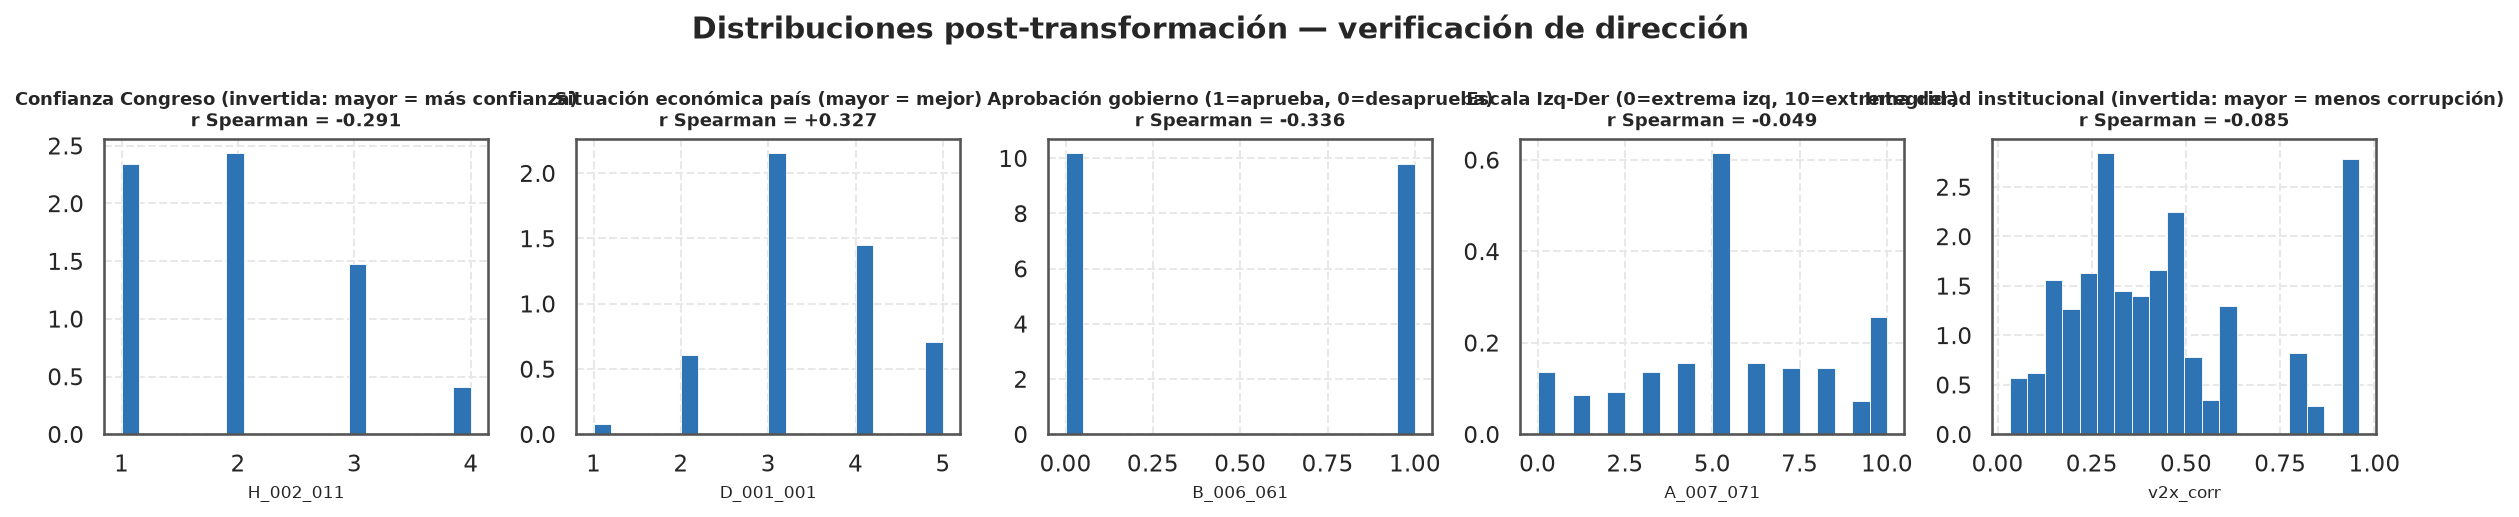

In [17]:
# =============================================================================
# EDA 2.1 — Verificación de inversiones: correlaciones post-transformación
# =============================================================================
VARS_VERIFICAR = {
    "H_002_011" : "Confianza Congreso (invertida: mayor = más confianza)",
    "D_001_001" : "Situación económica país (mayor = mejor)",
    "B_006_061" : "Aprobación gobierno (1=aprueba, 0=desaprueba)",
    "A_007_071" : "Escala Izq-Der (0=extrema izq, 10=extrema der)",
    "v2x_corr"  : "Integridad institucional (invertida: mayor = menos corrupción)",
}

fig, axes = plt.subplots(1, len(VARS_VERIFICAR), figsize=(16, 3.5))
for ax, (col, titulo) in zip(axes, VARS_VERIFICAR.items()):
    if col not in df.columns:
        ax.set_visible(False)
        continue
    x = pd.to_numeric(df[col], errors="coerce").dropna()
    y = df.loc[x.index, COL_TARGET]
    mask = y.notna()
    r, _ = stats.spearmanr(x[mask].values, y[mask].values)
    ax.hist(x.values, bins=20, color="#2E74B5", edgecolor="white",
            linewidth=0.4, density=True)
    ax.set_title(f"{titulo}\nr Spearman = {r:+.3f}", fontsize=8.5, fontweight="bold")
    ax.set_xlabel(col, fontsize=8)

fig.suptitle("Distribuciones post-transformación — verificación de dirección",
             fontweight="bold")
save_figure("eda2_distribuciones_post_transform.png")
plt.show()

In [18]:
# =============================================================================
# EDA 2.2 — Correlación de Spearman por subperiodo (criterio de selección)
#
# La correlación se calcula sobre el TRAIN de cada subperiodo para evitar
# cualquier contaminación del conjunto de test.
# =============================================================================
SP_TRAIN = {
    "SP1": [1995,1996,1997,1998,2000,2001,2002,2003,2004,2005],
    "SP2": [1995,1996,1997,1998,2000,2001,2002,2003,2004,2005,2006,
            2007,2008,2009,2010,2011,2013,2015,2016],
    "SP3": [1995,1996,1997,1998,2000,2001,2002,2003,2004,2005,2006,
            2007,2008,2009,2010,2011,2013,2015,2016,2017,2018,2020],
}

def corr_sp(feat, años):
    sub  = df[df[COL_AÑO].isin(años)].copy()
    x    = pd.to_numeric(sub[feat], errors="coerce")
    y    = sub[COL_TARGET]
    mask = x.notna() & y.notna()
    if mask.sum() < 50:
        return np.nan
    r, _ = stats.spearmanr(x[mask].values, y[mask].values)
    return r

print(f"{'Feature':<22} {'Etiqueta':<30} {'Bloque':<28} {'SP1':>7} {'SP2':>7} {'SP3':>7} {'MaxSP':>7}")
print("─" * 115)

REPORTE = {}
for feat in LB_FEATURES:
    if feat not in df.columns:
        continue
    rs     = {sp: corr_sp(feat, años) for sp, años in SP_TRAIN.items()}
    valid  = [r for r in rs.values() if not np.isnan(r)]
    max_sp = max(abs(r) for r in valid) if valid else 0
    signs  = [1 if r > 0.02 else (-1 if r < -0.02 else 0) for r in valid]
    inv    = len(set(s for s in signs if s != 0)) > 1
    REPORTE[feat] = {"rs": rs, "max_sp": max_sp, "inv": inv}

    et = ETIQUETAS_FEATURES.get(feat, feat)
    bl = bloque_de(feat)[:26]
    r1 = f"{rs['SP1']:+.3f}" if not np.isnan(rs["SP1"]) else "  NaN"
    r2 = f"{rs['SP2']:+.3f}" if not np.isnan(rs["SP2"]) else "  NaN"
    r3 = f"{rs['SP3']:+.3f}" if not np.isnan(rs["SP3"]) else "  NaN"
    inv_flag = " ↕" if inv else ""
    print(f"{feat:<22} {et:<30} {bl:<28} {r1:>7} {r2:>7} {r3:>7} {max_sp:>7.3f}{inv_flag}")

print()
n_clara = sum(1 for v in REPORTE.values() if v["max_sp"] >= 0.05)
n_debil = sum(1 for v in REPORTE.values() if 0.02 <= v["max_sp"] < 0.05)
n_no    = sum(1 for v in REPORTE.values() if v["max_sp"] < 0.02)
print(f"Señal clara  (max|r|≥0.05): {n_clara} variables")
print(f"Señal débil  (max|r|≥0.02): {n_debil} variables")
print(f"Sin señal    (max|r|<0.02): {n_no} variables")
print()
print("↕ = la relación con el target cambia de signo entre subperiodos")
print("    (estas variables son especialmente relevantes para el análisis de estabilidad)")

Feature                Etiqueta                       Bloque                           SP1     SP2     SP3   MaxSP
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────


H_002_011              Confianza Congreso             Confianza institucional       -0.235  -0.277  -0.284   0.284


H_002_031              Confianza Gobierno             Confianza institucional       -0.307  -0.364  -0.378   0.378


H_002_041              Confianza Poder Judicial       Confianza institucional       -0.221  -0.255  -0.264   0.264


H_002_101              Confianza Iglesia Católica     Confianza institucional       -0.071  -0.043  -0.052   0.071


...

S_002                  Edad                           Características sociodemog    -0.029  -0.028  -0.023   0.029


S_101                  Nivel educativo                Características sociodemog    +0.015  +0.010  +0.014   0.015


S_200                  Situación ocupacional          Características sociodemog    -0.013  -0.008  -0.010   0.013


S_301                  Nivel socioeconómico           Características sociodemog    +0.044  +0.043  +0.037   0.044


S_701                  Práctica religiosa             Características sociodemog    +0.021  +0.014  +0.014   0.021
X_008                  Tamaño municipio (urbano-rural) Características sociodemog    +0.077  +0.040  +0.044   0.077

Señal clara  (max|r|≥0.05): 24 variables
Señal débil  (max|r|≥0.02): 3 variables
Sin señal    (max|r|<0.02): 3 variables

↕ = la relación con el target cambia de signo entre subperiodos
    (estas variables son especialmente relevantes para el análisis de estabilidad)


  ✓ Figura guardada: eda2_correlaciones_subperiodo.png.png


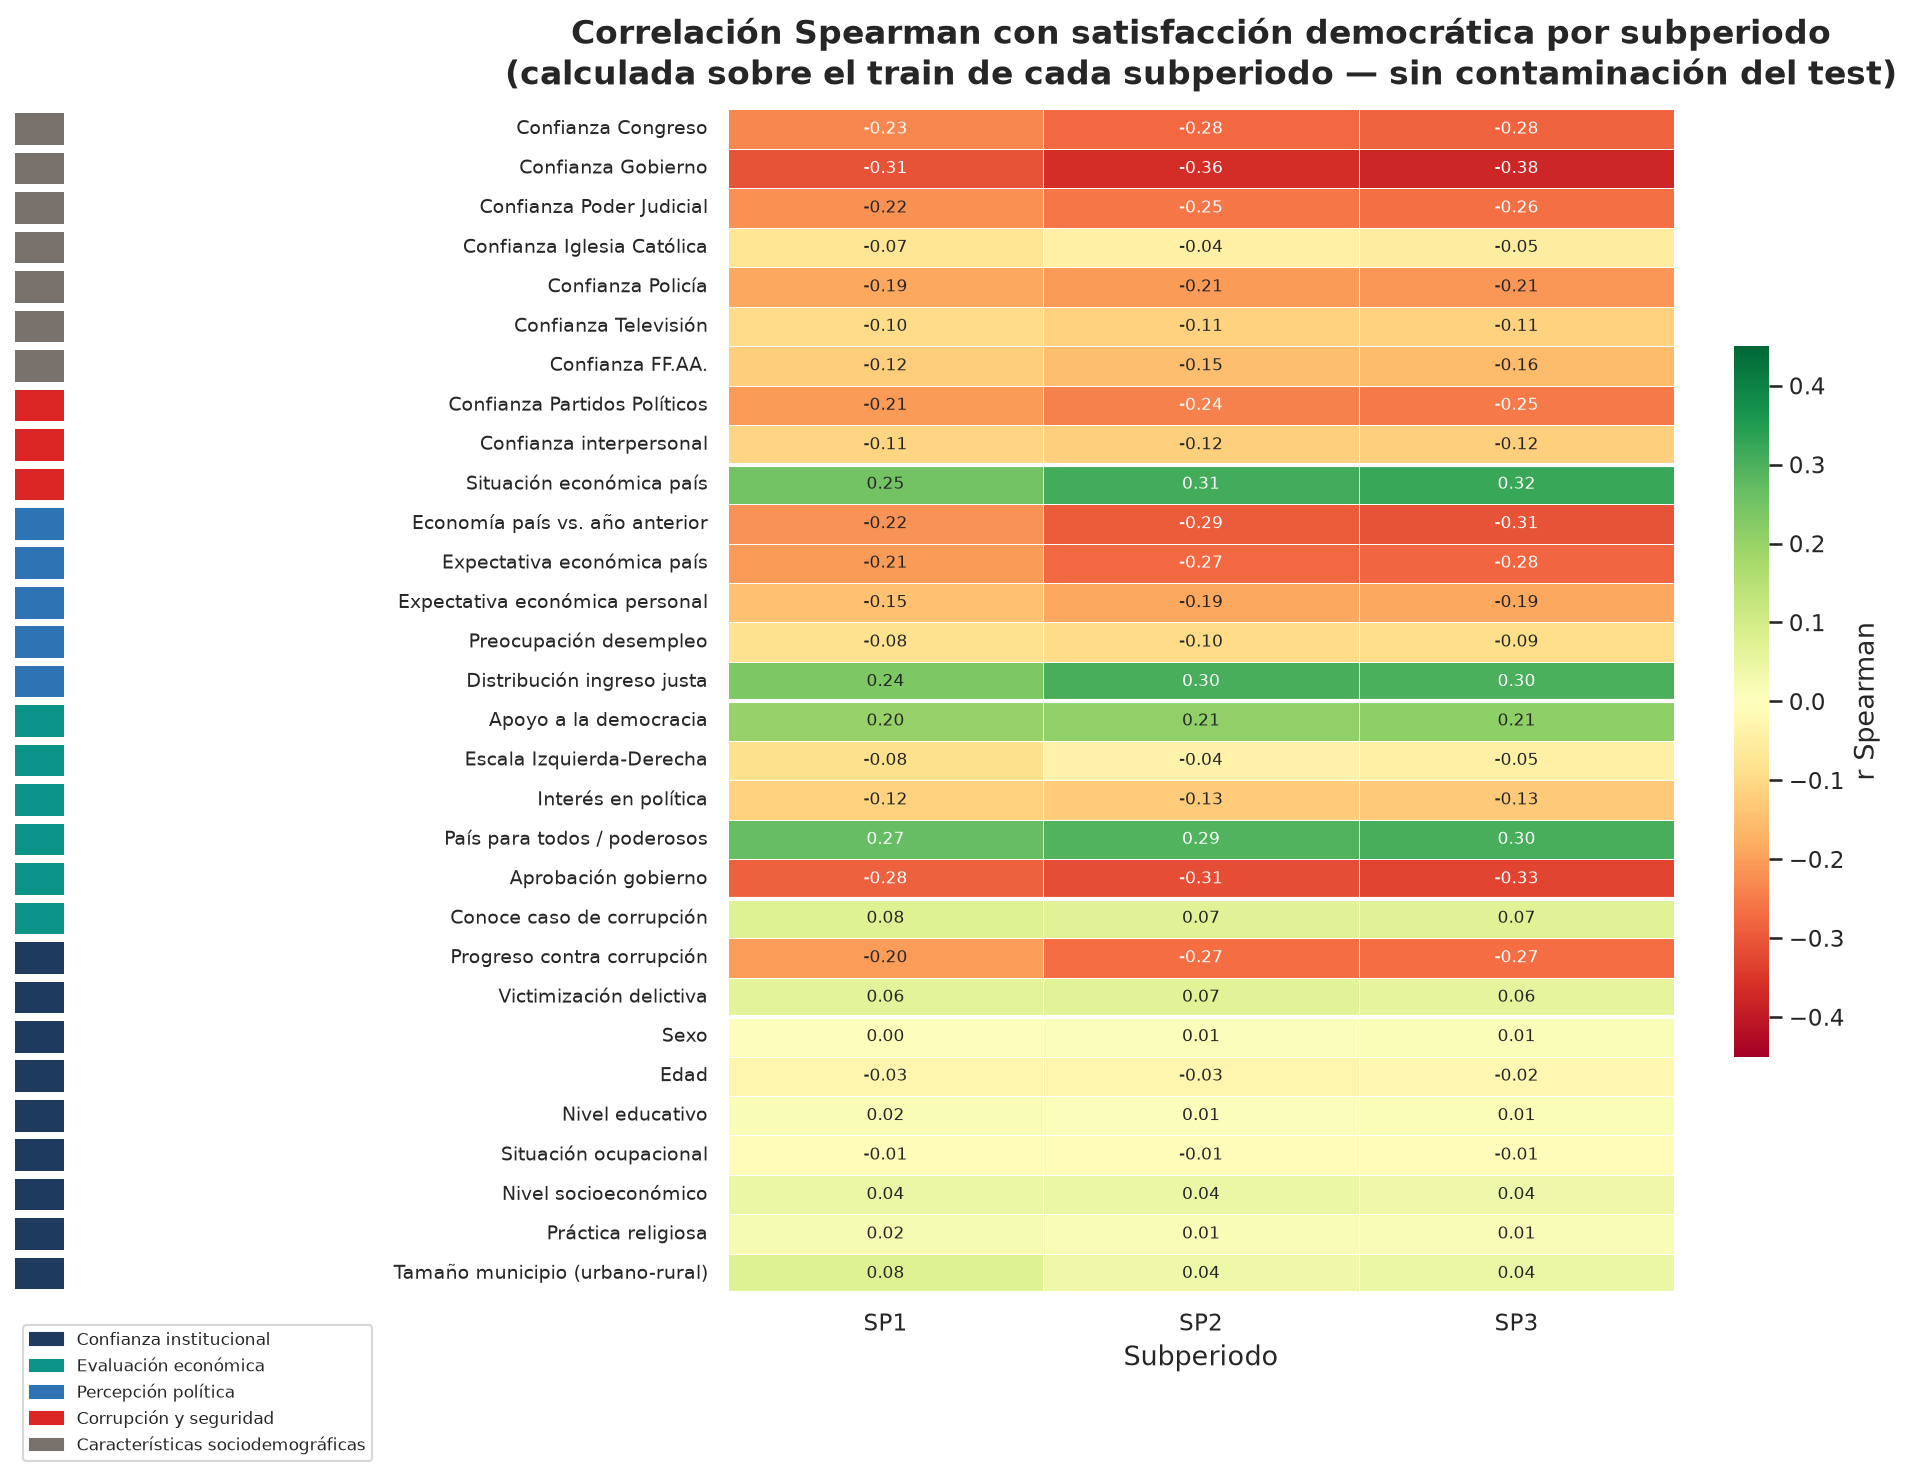

✓ Heatmap de correlaciones por subperiodo guardado


In [19]:
# =============================================================================
# EDA 2.3 — Heatmap de correlaciones por subperiodo, organizado por bloques
# =============================================================================
# Construir matriz de correlaciones con variables ordenadas por bloque temático
vars_ordenadas = []
bloques_labels = []
for bloque in THEME["blocks"]:
    for v in BLOQUES[bloque]:
        if v in df.columns:
            vars_ordenadas.append(v)
            bloques_labels.append(bloque)

# Calcular correlaciones para cada variable en el orden definido
rs_data = {}
for feat in vars_ordenadas:
    rs_data[feat] = {
        sp: corr_sp(feat, años) for sp, años in SP_TRAIN.items()
    }

df_rs = pd.DataFrame(rs_data, index=["SP1","SP2","SP3"]).T
# Etiquetas cortas para eje Y
df_rs.index = [ETIQUETAS_FEATURES.get(c, c) for c in vars_ordenadas]

fig, (ax_bar, ax_heat) = plt.subplots(
    1, 2, figsize=(13, 10),
    gridspec_kw={"width_ratios": [0.04, 0.96]},
)

# Barra lateral de bloques
for i, (feat, bloque) in enumerate(zip(vars_ordenadas, bloques_labels)):
    ax_bar.barh(i, 1, color=THEME["blocks"][bloque], edgecolor="none")
ax_bar.set_xlim(0, 1)
ax_bar.set_ylim(-0.5, len(vars_ordenadas) - 0.5)
ax_bar.axis("off")

# Leyenda de bloques
patches = [mpatches.Patch(color=c, label=b)
           for b, c in THEME["blocks"].items()]
ax_bar.legend(handles=patches, loc="upper left",
              bbox_to_anchor=(0, -0.02), fontsize=8, frameon=True)

# Heatmap principal
sns.heatmap(
    df_rs, annot=True, fmt=".2f", cmap="RdYlGn",
    center=0, vmin=-0.45, vmax=0.45,
    linewidths=0.3, ax=ax_heat,
    annot_kws={"size": 8},
    cbar_kws={"label": "r Spearman", "shrink": 0.6},
)
ax_heat.set_title(
    "Correlación Spearman con satisfacción democrática por subperiodo\n"
    "(calculada sobre el train de cada subperiodo — sin contaminación del test)",
    fontweight="bold", pad=12,
)
ax_heat.set_xlabel("Subperiodo")
ax_heat.set_ylabel("")
ax_heat.tick_params(axis="y", labelsize=9)

# Líneas separadoras entre bloques
n_acum = 0
for bloque in THEME["blocks"]:
    n_acum += len([v for v in BLOQUES[bloque] if v in df.columns])
    ax_heat.axhline(n_acum, color="white", linewidth=2)

save_figure("eda2_correlaciones_subperiodo.png")
plt.show()
print("✓ Heatmap de correlaciones por subperiodo guardado")

## 10. Construcción de los splits temporales (Expanding Window)

In [20]:
# construir_split y resumen_split importadas desde utils.preprocessing
print("✓ construir_split / resumen_split disponibles desde utils.preprocessing")

✓ construir_split / resumen_split disponibles desde utils.preprocessing


## 11. Imputación diferenciada y normalización

Estrategia por tipo de modelo:
- **OLO y TabNet**: MICE (`IterativeImputer` + `BayesianRidge`) para numéricas,
  moda para categóricas. Requieren matrices completas.
- **XGBoost, LightGBM, CatBoost**: reciben datos con NaN nativos; cada
  algoritmo tiene su propio mecanismo interno de manejo de valores faltantes.

> **Anti-data leakage:** el imputador se ajusta exclusivamente sobre el
> conjunto de entrenamiento de cada split.

In [21]:
# imputar y normalizar importadas desde utils.preprocessing
print("✓ imputar / normalizar disponibles desde utils.preprocessing")

✓ imputar / normalizar disponibles desde utils.preprocessing


## 12. Función de evaluación unificada

In [22]:
from typing import List, Dict
# evaluar importada desde utils.metrics
RESULTADOS: List[Dict] = []
print("✓ evaluar disponible desde utils.metrics | RESULTADOS inicializado.")

✓ evaluar disponible desde utils.metrics | RESULTADOS inicializado.


## 13. Modelo 1 — Regresión Logística Ordinal (Baseline)

In [23]:
# entrenar_olo importada desde utils.models
print("✓ entrenar_olo disponible desde utils.models")

✓ entrenar_olo disponible desde utils.models


## 14. Modelo 2 — XGBoost

In [24]:
# entrenar_xgboost importada desde utils.models
print("✓ entrenar_xgboost disponible desde utils.models")

✓ entrenar_xgboost disponible desde utils.models


## 15. Modelo 3 — CatBoost

In [25]:
# entrenar_catboost importada desde utils.models
print("✓ entrenar_catboost disponible desde utils.models")

✓ entrenar_catboost disponible desde utils.models


## 16. Modelo 4 — LightGBM

In [26]:
# entrenar_lightgbm importada desde utils.models
print("✓ entrenar_lightgbm disponible desde utils.models")

✓ entrenar_lightgbm disponible desde utils.models


## 17. Modelo 5 — TabNet

In [27]:
# entrenar_tabnet importada desde utils.models
print("✓ entrenar_tabnet disponible desde utils.models")

✓ entrenar_tabnet disponible desde utils.models


## 18. Ciclo principal de entrenamiento y guardado del pipeline

Por cada subperiodo se entrenan los 5 modelos y se guarda el **pipeline completo**
como artefacto autónomo que incluye el modelo, los preprocesadores ajustados y
la metadata necesaria para reproducir predicciones en producción.

In [28]:
# =============================================================================
# Ciclo principal — SP1 → SP2 → SP3
# =============================================================================
PIPELINES: Dict[str, Dict] = {}

for sp, cfg_sp in SUBPERIODOS.items():
    print()
    print("#" * 60)
    print(f"# SUBPERIODO: {sp} — {cfg_sp['descripcion']}")
    print("#" * 60)

    # ── Splits ────────────────────────────────────────────────────────────────
    X_tr_t, y_tr, X_val_t, y_val, X_te_t, y_te, w_tr, w_val, w_te = construir_split(df, sp, FEATURES_TREES, PESOS_CLASE)
    X_tr_o, y_tr_o, X_val_o, y_val_o, X_te_o, y_te_o, w_tr_o, w_val_o, _ = construir_split(df, sp, FEATURES_OLO, PESOS_CLASE)
    resumen_split(sp, X_tr_t, y_tr, X_val_t, y_val, X_te_t, y_te)

    # ── Imputación para OLO y TabNet ──────────────────────────────────────────
    print("\n  [Imputación MICE...]")
    X_tr_oi, X_val_oi, X_te_oi, imp_num_olo, imp_cat_olo = imputar(X_tr_o, X_val_o, X_te_o)
    X_tr_ti, X_val_ti, X_te_ti, imp_num_tab, imp_cat_tab = imputar(X_tr_t, X_val_t, X_te_t)

    # ── Normalización ─────────────────────────────────────────────────────────
    print("  [Normalización...]")
    X_tr_os, X_val_os, X_te_os, sc_olo = normalizar(X_tr_oi, X_val_oi, X_te_oi, "standard")
    X_tr_ts, X_val_ts, X_te_ts, sc_tab = normalizar(X_tr_ti, X_val_ti, X_te_ti, "minmax")

    # ── Índices de categóricas para TabNet ────────────────────────────────────
    cols_tn  = list(X_tr_ts.columns)
    cat_idxs = [i for i, c in enumerate(cols_tn) if c in VARS_CATEGORICAS]
    cat_dims = [int(X_tr_ts[c].nunique()) + 1 for c in VARS_CATEGORICAS if c in cols_tn]

    # ── Guardar datasets procesados en Parquet ────────────────────────────────
    # NOTA: estos Parquet contienen NaN originales (pre-imputación).
    # Son correctos para los modelos de árboles (XGBoost, CatBoost, LightGBM)
    # que manejan NaN nativamente. Para OLO y TabNet, aplicar el imputer del
    # artefacto correspondiente antes de predecir (ver utils/io.py).
    print("\n  [Guardando datasets en Parquet...]")
    X_tr_t.assign(target=y_tr.values).to_parquet(
        PATHS["FOLDER_PROCS"] / f"{sp}_train.parquet", index=False)
    X_val_t.assign(target=y_val.values).to_parquet(
        PATHS["FOLDER_PROCS"] / f"{sp}_val.parquet", index=False)
    X_te_t.assign(target=y_te.values).to_parquet(
        PATHS["FOLDER_PROCS"] / f"{sp}_test.parquet", index=False)
    pd.DataFrame({"sample_weight": w_tr}).to_parquet(
        PATHS["FOLDER_PROCS"] / f"{sp}_train_weights.parquet", index=False)
    pd.DataFrame({"sample_weight": w_val}).to_parquet(
        PATHS["FOLDER_PROCS"] / f"{sp}_val_weights.parquet", index=False)
    # Registrar qué variables tienen 100% NaN en test para auditoría posterior
    vars_nan_test = {
        col: float(X_te_t[col].isna().mean()) * 100
        for col in X_te_t.columns if X_te_t[col].isna().any()
    }
    import json as _json
    (_json_path := PATHS["FOLDER_PROCS"] / f"{sp}_nan_audit.json") and         _json_path.write_text(_json.dumps(vars_nan_test, indent=2))

    # ── Entrenamiento ─────────────────────────────────────────────────────────
    clf_olo, m_olo_val, m_olo_te = entrenar_olo(
        X_tr_os.values, y_tr_o.values,
        X_val_os.values, y_val_o.values,
        X_te_os.values, y_te_o.values, w_tr_o, w_val_o, sp, HW_CFG)
    RESULTADOS.extend([m_olo_val, m_olo_te])

    clf_xgb, m_xgb_val, m_xgb_te = entrenar_xgboost(
        X_tr_t, y_tr, X_val_t, y_val, X_te_t, y_te, w_tr, w_val, sp, HW_CFG)
    RESULTADOS.extend([m_xgb_val, m_xgb_te])

    clf_cb, m_cb_val, m_cb_te = entrenar_catboost(
        X_tr_t, y_tr, X_val_t, y_val, X_te_t, y_te, w_tr, w_val, sp, HW_CFG)
    RESULTADOS.extend([m_cb_val, m_cb_te])

    clf_lgb, m_lgb_val, m_lgb_te = entrenar_lightgbm(
        X_tr_t, y_tr, X_val_t, y_val, X_te_t, y_te, w_tr, w_val, sp, PESOS_CLASE, HW_CFG)
    RESULTADOS.extend([m_lgb_val, m_lgb_te])

    clf_tn, m_tn_val, m_tn_te = entrenar_tabnet(
        X_tr_ts.values, y_tr.values,
        X_val_ts.values, y_val.values,
        X_te_ts.values, y_te.values, sp, cat_idxs, cat_dims, HW_CFG)
    RESULTADOS.extend([m_tn_val, m_tn_te])

    # ── Pipeline completo por modelo y subperiodo ─────────────────────────────
    for nombre_m, clf_m, tipo in [
        ("OLO",     clf_olo, "olo"),
        ("XGBoost", clf_xgb, "trees"),
        ("CatBoost",clf_cb,  "trees"),
        ("LightGBM",clf_lgb, "trees"),
        ("TabNet",  clf_tn,  "tabnet"),
    ]:
        # Identificar variables con 100% NaN en el test (imputación total)
        # Se guarda en el artefacto para documentar las limitaciones en NB03-06.
        vars_100nan_test = [
            col for col in (FEATURES_OLO if tipo == "olo" else FEATURES_TREES)
            if col in X_te_t.columns and X_te_t[col].isna().all()
        ]

        artefacto = {
            "modelo"            : clf_m,
            "tipo_modelo"       : tipo,
            "nombre_modelo"     : nombre_m,
            "subperiodo"        : sp,
            "vars_100nan_test"  : vars_100nan_test,  # variables con imputación total en test
            "imp_num"           : imp_num_olo if tipo == "olo" else (
                                  imp_num_tab if tipo == "tabnet" else None),
            "imp_cat"           : imp_cat_olo if tipo == "olo" else (
                                  imp_cat_tab if tipo == "tabnet" else None),
            "scaler"            : sc_olo      if tipo == "olo" else (
                                  sc_tab      if tipo == "tabnet" else None),
            "features"          : FEATURES_OLO if tipo == "olo" else FEATURES_TREES,
            "vars_categoricas"  : VARS_CATEGORICAS,
            "cat_idxs_tabnet"   : cat_idxs if tipo == "tabnet" else None,
            "cat_dims_tabnet"   : cat_dims  if tipo == "tabnet" else None,
            "etiquetas_features": ETIQUETAS_FEATURES,
            "bloques"           : BLOQUES,
            "transformaciones"  : {
                "nsnr"            : NSNR,
                "likert4"         : VARS_LIKERT4_INVERTIR,
                "likert4_interes" : VARS_LIKERT4_INTERES,
                "binarias"        : {
                    "B_006_061": {1:1, 2:0},
                    "B_001_101": {1:1, 2:0},
                    "H_001_011": {1:1, 2:0},
                    "S_001"    : {1:0, 2:1},
                },
                "vdem_invertir"   : VARS_VDEM_INVERTIR,
                "a007071_nsnr_97" : True,
                "c003003_nan5"    : True,
            },
            "version_pipeline"  : "2.1.0",
            "fecha_entrenamiento": datetime.now().isoformat(),
            "etiquetas_target"  : ETIQUETAS,
            "pesos_clase"       : PESOS_CLASE,
        }
        ruta_art = PATHS["FOLDER_MODELS"] / f"pipeline_{nombre_m}_{sp}.pkl"
        joblib.dump(artefacto, ruta_art)
        PIPELINES[f"{nombre_m}_{sp}"] = artefacto
        print(f"  ✓ Pipeline guardado: pipeline_{nombre_m}_{sp}.pkl")

    gc.collect()
    print(f"\n✓ {sp} completado.")

print()
print("=" * 60)
print("✅ CICLO COMPLETO FINALIZADO")
print(f"   Pipelines guardados: {len(PIPELINES)}")
print("=" * 60)


############################################################
# SUBPERIODO: SP1 — Consolidación democrática (1995–2007)
############################################################


────────────────────────────────────────────────────
  SP1
────────────────────────────────────────────────────
  Train :  166,979 registros | 45 features
  Val   :   19,366 registros
  Test  :   19,371 registros
  Ratio train/test: 8.6x
  Clases train : {0: np.int64(14612), 1: np.int64(41939), 2: np.int64(75149), 3: np.int64(35279)}
  Clases val   : {0: np.int64(1707), 1: np.int64(5889), 2: np.int64(8181), 3: np.int64(3589)}
  Clases test  : {0: np.int64(1714), 1: np.int64(5684), 2: np.int64(8447), 3: np.int64(3526)}


  NaN train: 15.7%  |  NaN val: 7.5%  |  NaN test: 5.2%

  [Imputación MICE...]


  [Normalización...]

  [Guardando datasets en Parquet...]


====================================================  Entrenando OLO — SP1  ====================================================


...

  Mejor Kappa Val: 0.5437 | {'n_d': 24, 'n_a': 64, 'n_steps': 6, 'gamma': 1.5986584841970366, 'lambda_sparse': 2.9380279387035354e-06, 'momentum': 0.07083786293111903, 'mask_type': 'entmax', 'lr': 0.0015930522616241021}



Early stopping occurred at epoch 84 with best_epoch = 64 and best_val_0_balanced_accuracy = 0.51159


Successfully saved model at ../models/TabNet_SP3.zip
  ✓ Guardado: TabNet_SP3.zip
  ⚠ Limitación: TabNet usa pesos por clase, no sample_weight individual.
  ────────────────────────────────────────────────
  TabNet — SP3 [val]
  ────────────────────────────────────────────────
    split: val
    balanced_accuracy     : 0.5116
    f1_macro              : 0.4693
    f1_weighted           : 0.4661
    kappa_lineal          : 0.4245
    kappa_cuadratico      : 0.5437
    mae_ordinal           : 0.6502
    auroc_macro           : 0.7682
  ────────────────────────────────────────────────
  TabNet — SP3 [test]
  ────────────────────────────────────────────────
    split: test
    balanced_accuracy     : 0.4898
    f1_macro              : 0.4498
    f1_weighted           : 0.4475
    kappa_lineal          : 0.4107
    kappa_cuadratico      : 0.5332
    mae_ordinal           : 0.6806
    auroc_macro           : 0.7561
  ✓ Pipeline guardado: pipeline_OLO_SP3.pkl
  ✓ Pipeline guardado: pipeline_X

  ✓ Pipeline guardado: pipeline_LightGBM_SP3.pkl
  ✓ Pipeline guardado: pipeline_TabNet_SP3.pkl



✓ SP3 completado.

✅ CICLO COMPLETO FINALIZADO
   Pipelines guardados: 15


## 19. Función de predicción en producción

La función `predecir()` encapsula el pipeline completo para cualquier modelo.
Recibe los valores **originales del cuestionario** y aplica internamente
todas las transformaciones necesarias en el orden correcto.

In [29]:
# aplicar_transformaciones_deterministas y predecir importadas desde utils
print("✓ aplicar_transformaciones_deterministas disponible desde utils.preprocessing")
print("✓ predecir disponible desde utils.models")

✓ aplicar_transformaciones_deterministas disponible desde utils.preprocessing
✓ predecir disponible desde utils.models


## 20. Tabla comparativa de resultados

In [30]:
# =============================================================================
# Tabla comparativa de métricas por modelo y subperiodo
# =============================================================================
df_res = pd.DataFrame(RESULTADOS)
df_res = df_res.sort_values(["subperiodo","kappa_cuadratico"],
                             ascending=[True, False])

cols_show = ["modelo","subperiodo","split","balanced_accuracy","f1_macro",
             "kappa_lineal","kappa_cuadratico","mae_ordinal","auroc_macro"]
print("Métricas por modelo y subperiodo:")
print(df_res[[c for c in cols_show if c in df_res.columns]].to_string(
    index=False, float_format="{:.4f}".format))

print("\nKappa Cuadrático (modelo × subperiodo):")
pivot = df_res[df_res["split"]=="test"].pivot(index="modelo", columns="subperiodo",
                     values="kappa_cuadratico")
print(pivot.to_string(float_format="{:.4f}".format))

df_res.to_csv(PATHS["FILE_RESULTS_MODEL_CSV"], index=False)
df_res.to_parquet(PATHS["FILE_RESULTS_MODEL_PARQUET"], index=False)
print("\n✓ Resultados guardados en results/")

Métricas por modelo y subperiodo:
  modelo subperiodo split  balanced_accuracy  f1_macro  kappa_lineal  kappa_cuadratico  mae_ordinal  auroc_macro
 XGBoost        SP1   val             0.4978    0.4846        0.3949            0.5025       0.5913       0.7602
 XGBoost        SP1  test             0.4838    0.4673        0.3822            0.5005       0.6062       0.7550
CatBoost        SP1   val             0.4994    0.4767        0.3908            0.5000       0.6105       0.7561
CatBoost        SP1  test             0.4979    0.4555        0.3757            0.4867       0.6529       0.7545
  TabNet        SP1   val             0.4859    0.4190        0.3562            0.4758       0.7217       0.7370
LightGBM        SP1  test             0.4514    0.4114        0.3382            0.4607       0.6847       0.7209
     OLO        SP1   val             0.4686    0.3891        0.3307            0.4554       0.7838       0.7370
LightGBM        SP1   val             0.4586    0.4052        

## 21. Visualización comparativa de rendimiento

  ✓ Figura guardada: rendimiento_comparativo.png.png


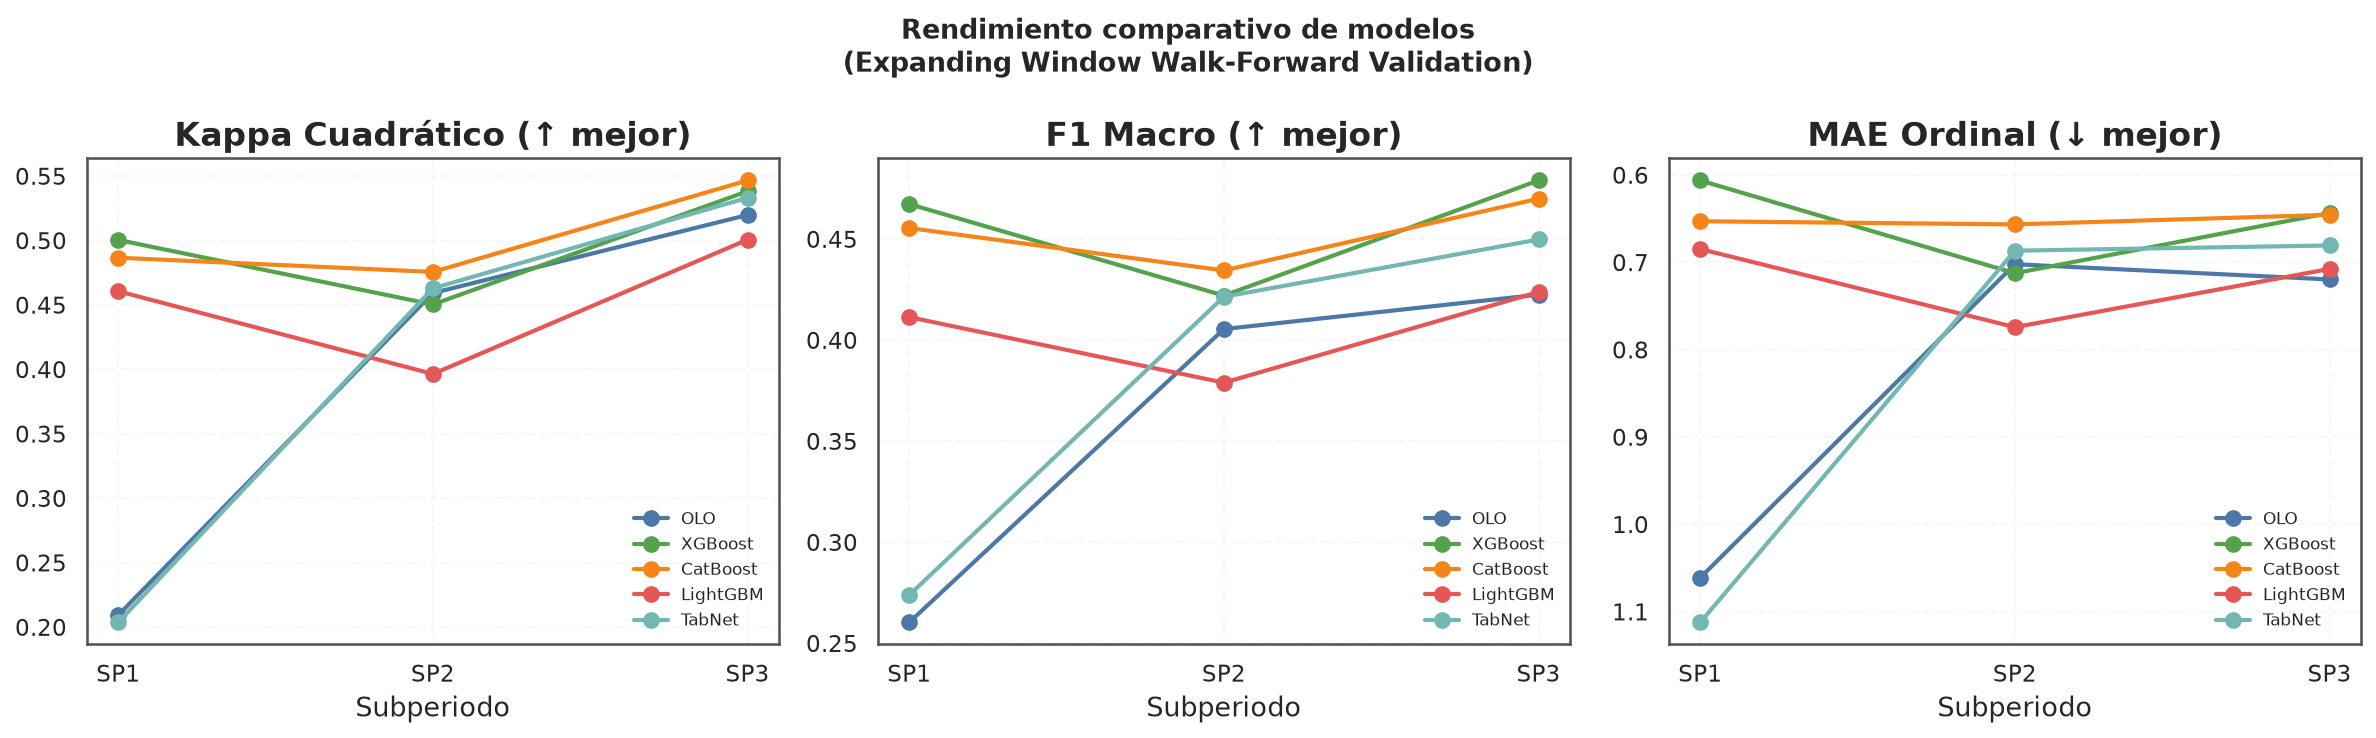

✓ Figura guardada: rendimiento_comparativo.png


In [31]:
# =============================================================================
# Gráficos de rendimiento por modelo y subperiodo
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "Rendimiento comparativo de modelos\n"
    "(Expanding Window Walk-Forward Validation)",
    fontsize=13, fontweight="bold",
)

metricas_plot = [
    ("kappa_cuadratico", "Kappa Cuadrático (↑ mejor)"),
    ("f1_macro",         "F1 Macro (↑ mejor)"),
    ("mae_ordinal",      "MAE Ordinal (↓ mejor)"),
]
modelos_orden = ["OLO","XGBoost","CatBoost","LightGBM","TabNet"]
colores_dict  = {m: THEME["models"].get(m, "#888888") for m in modelos_orden}

for ax, (metrica, titulo) in zip(axes, metricas_plot):
    for modelo in ["OLO","XGBoost","CatBoost","LightGBM","TabNet"]:
        sub = df_res[(df_res["modelo"] == modelo) & (df_res["split"] == "test")]
        if sub.empty or metrica not in sub.columns:
            continue
        ax.plot(sub["subperiodo"], sub[metrica],
                marker="o", linewidth=2, markersize=7,
                label=modelo, color=colores_dict.get(modelo, "#888888"))
    ax.set_title(titulo, fontweight="bold")
    ax.set_xlabel("Subperiodo")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    if metrica == "mae_ordinal":
        ax.invert_yaxis()

save_figure("rendimiento_comparativo.png")
plt.show()
print("✓ Figura guardada: rendimiento_comparativo.png")

## 22. Registro de versiones y entorno

In [32]:
# =============================================================================
# Registro de versiones para reproducibilidad
# =============================================================================
import importlib, platform, sys

libs = ["pandas","numpy","sklearn","xgboost","lightgbm",
        "catboost","pytorch_tabnet","optuna","torch","missingno","joblib"]

print(f"Fecha          : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Python         : {sys.version.split()[0]}")
print(f"Sistema        : {platform.system()} {platform.release()}")
print(f"Semilla global : {PARAMETERS['SEED']}")
print(f"GPU usada      : {USAR_GPU}")
print()
print("Versiones de librerías:")
for lib in libs:
    try:
        ver = getattr(importlib.import_module(lib), "__version__", "N/D")
        print(f"  {lib:<20}: {ver}")
    except ImportError:
        print(f"  {lib:<20}: NO INSTALADA")

Fecha          : 2026-07-16 17:12:29
Python         : 3.12.3
Sistema        : Linux 6.17.0-35-generic
Semilla global : 42
GPU usada      : True

Versiones de librerías:
  pandas              : 3.0.3
  numpy               : 2.4.6
  sklearn             : 1.9.0
  xgboost             : 3.3.0
  lightgbm            : 4.6.0
  catboost            : 1.2.10
  pytorch_tabnet      : N/D
  optuna              : 4.9.0
  torch               : 2.13.0+cu130
  missingno           : 0.5.2
  joblib              : 1.5.3
